In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import pandas as pd

In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
df = pd.read_csv('../data/criterion_x86.csv')
df

,row_index,benchmark,backend,architecture,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count
0,0,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,998407.0,ns,15290
1,1,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,1988499.0,ns,30580
2,2,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,2989501.0,ns,45870
3,3,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,3984812.0,ns,61160
4,4,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,4936903.0,ns,76450
...,...,...,...,...,...,...,...,...,...,...,...,...
15595,25,engine,avx2,x86_64,encrypt_inflight,32_64,1.0,256,elements,279754325.0,ns,411190
15596,26,engine,avx2,x86_64,encrypt_inflight,32_64,1.0,256,elements,290866687.0,ns,427005
15597,27,engine,avx2,x86_64,encrypt_inflight,32_64,1.0,256,elements,297544115.0,ns,442820
15598,28,engine,avx2,x86_64,encrypt_inflight,32_64,1.0,256,elements,314096763.0,ns,458635


In [5]:
speck = df[df['benchmark'] == 'speck']
speck = speck.drop(columns=['benchmark', 'suffix', 'unit', 'throughput_type'])
speck['time_per_iter_ns'] = speck['sample_measured_value'] / speck['iteration_count']

speck['keys_per_sec'] = (
        speck['throughput_num'] / (speck['time_per_iter_ns'] / 1e9)
)
speck

,row_index,backend,architecture,function,version,throughput_num,sample_measured_value,iteration_count,time_per_iter_ns,keys_per_sec
0,0,sse2,x86_64,decrypt,128_256,2,998407.0,15290,65.298038,3.062879e+07
1,1,sse2,x86_64,decrypt,128_256,2,1988499.0,30580,65.026128,3.075687e+07
2,2,sse2,x86_64,decrypt,128_256,2,2989501.0,45870,65.173338,3.068740e+07
3,3,sse2,x86_64,decrypt,128_256,2,3984812.0,61160,65.153891,3.069655e+07
4,4,sse2,x86_64,decrypt,128_256,2,4936903.0,76450,64.576887,3.097083e+07
...,...,...,...,...,...,...,...,...,...,...
11995,95,avx2,x86_64,encrypt,32_64,16,96129885.0,3418560,28.119994,5.689902e+08
11996,96,avx2,x86_64,encrypt,32_64,16,95662601.0,3454170,27.694816,5.777255e+08
11997,97,avx2,x86_64,encrypt,32_64,16,98132620.0,3489780,28.120002,5.689900e+08
11998,98,avx2,x86_64,encrypt,32_64,16,97635030.0,3525390,27.694817,5.777254e+08


In [6]:
from scipy.stats import theilslopes
import pandas as pd
import numpy as np

group_cols = ['backend', 'architecture', 'function', 'version']
results = []

for keys, group in speck.groupby(group_cols):
    x = group['iteration_count'].values
    y = group['sample_measured_value'].values

    slope, intercept, ci_low, ci_high = theilslopes(y, x, 0.95)

    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    keys_per_iter = group['throughput_num'].iloc[0]
    keys_per_sec = keys_per_iter / (slope / 1e9)

    results.append({
        **dict(zip(group_cols, keys)),
        'time_per_iter_ns': slope,
        'ci_95_low_ns': ci_low,
        'ci_95_high_ns': ci_high,
        'intercept_ns': intercept,
        'r2': r2,
        'keys_per_sec': keys_per_sec,
        'Mkeys_per_sec': keys_per_sec / 1e6,
    })

speck_reg = pd.DataFrame(results)
speck_reg

,backend,architecture,function,version,time_per_iter_ns,ci_95_low_ns,ci_95_high_ns,intercept_ns,r2,keys_per_sec,Mkeys_per_sec
0,avx2,x86_64,decrypt,128_128,65.710532,65.655374,65.795853,-11286.389717,0.999930,6.087304e+07,60.873042
1,avx2,x86_64,decrypt,128_192,63.717418,63.561172,63.864724,8534.457486,0.999722,6.277718e+07,62.777183
2,avx2,x86_64,decrypt,128_256,65.588616,65.471804,65.697682,-45881.241319,0.999813,6.098619e+07,60.986193
3,avx2,x86_64,decrypt,32_64,38.483529,38.443400,38.525008,532408.567353,0.999577,4.157623e+08,415.762290
4,avx2,x86_64,decrypt,48_72,50.752994,50.749062,50.753132,-119354.039409,0.999974,1.576262e+08,157.626167
...,...,...,...,...,...,...,...,...,...,...,...
115,sse2,x86_64,encrypt_inflight,48_96,32.296376,32.263010,32.305216,1875.105351,0.999510,1.238529e+08,123.852905
116,sse2,x86_64,encrypt_inflight,64_128,32.336628,32.235942,32.472469,182394.577586,0.994057,1.236987e+08,123.698735
117,sse2,x86_64,encrypt_inflight,64_96,26.938330,26.934653,26.949930,-83764.133258,0.986852,1.484873e+08,148.487306
118,sse2,x86_64,encrypt_inflight,96_144,61.584132,61.553458,61.619488,33784.219444,0.999926,3.247590e+07,32.475898


In [7]:
print(f"Min R^2: {speck_reg['r2'].min():.6f}")
print(f"Czy wszystkie > 0.99: {(speck_reg['r2'] > 0.99).all()}")

print(speck_reg[speck_reg['r2'] <= 0.99][['backend', 'function', 'version', 'r2']])

Min R^2: 0.875531
Czy wszystkie > 0.99: False
    backend          function  version        r2
62   scalar           decrypt  128_256  0.875531
117    sse2  encrypt_inflight    64_96  0.986852


In [8]:
speck_pivot = speck_reg.pivot_table(
    index=['backend', 'version'],
    columns='function',
    values='Mkeys_per_sec'
).round(2).reset_index()

speck_pivot.columns.name = None

version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']
backend_order = ['scalar', 'sse2', 'avx2', 'avx512']

speck_pivot['backend'] = pd.Categorical(speck_pivot['backend'], categories=backend_order, ordered=True)
speck_pivot['version'] = pd.Categorical(speck_pivot['version'], categories=version_order, ordered=True)

speck_pivot = speck_pivot.sort_values(['backend', 'version']).reset_index(drop=True)

speck_pivot

,backend,version,decrypt,encrypt,encrypt_inflight
0,scalar,32_64,37.50,64.10,64.11
1,scalar,48_72,18.04,33.20,37.17
2,scalar,48_96,17.15,31.08,32.02
3,scalar,64_96,28.04,39.11,39.08
4,scalar,64_128,26.95,36.37,35.89
5,scalar,96_96,11.91,24.63,24.78
6,scalar,96_144,12.21,22.38,23.28
7,scalar,128_128,18.18,43.67,44.33
8,scalar,128_192,19.41,37.33,39.65
9,scalar,128_256,20.26,34.40,40.05


In [9]:
speck_pivot['version'] = speck_pivot['version'].str.replace('_', '/', regex=False)
speck_pivot.to_csv('../csv/speck_pivot.csv', index=False)

In [10]:
speck_pivot_mean = speck_pivot.groupby('backend')[['decrypt', 'encrypt', 'encrypt_inflight']].mean().reset_index()

backend_order = ['scalar', 'sse2', 'avx2', 'avx512']
speck_pivot_mean['backend'] = pd.Categorical(speck_pivot_mean['backend'], categories=backend_order, ordered=True)
speck_pivot_mean = speck_pivot_mean.sort_values('backend')

speck_pivot_mean = speck_pivot_mean.set_index('backend')[['decrypt', 'encrypt', 'encrypt_inflight']]
speck_pivot_mean

,decrypt,encrypt,encrypt_inflight
backend,,,
scalar,20.965,36.627,38.036
sse2,68.139,89.384,111.261
avx2,135.527,177.601,177.490
avx512,205.570,233.947,233.615


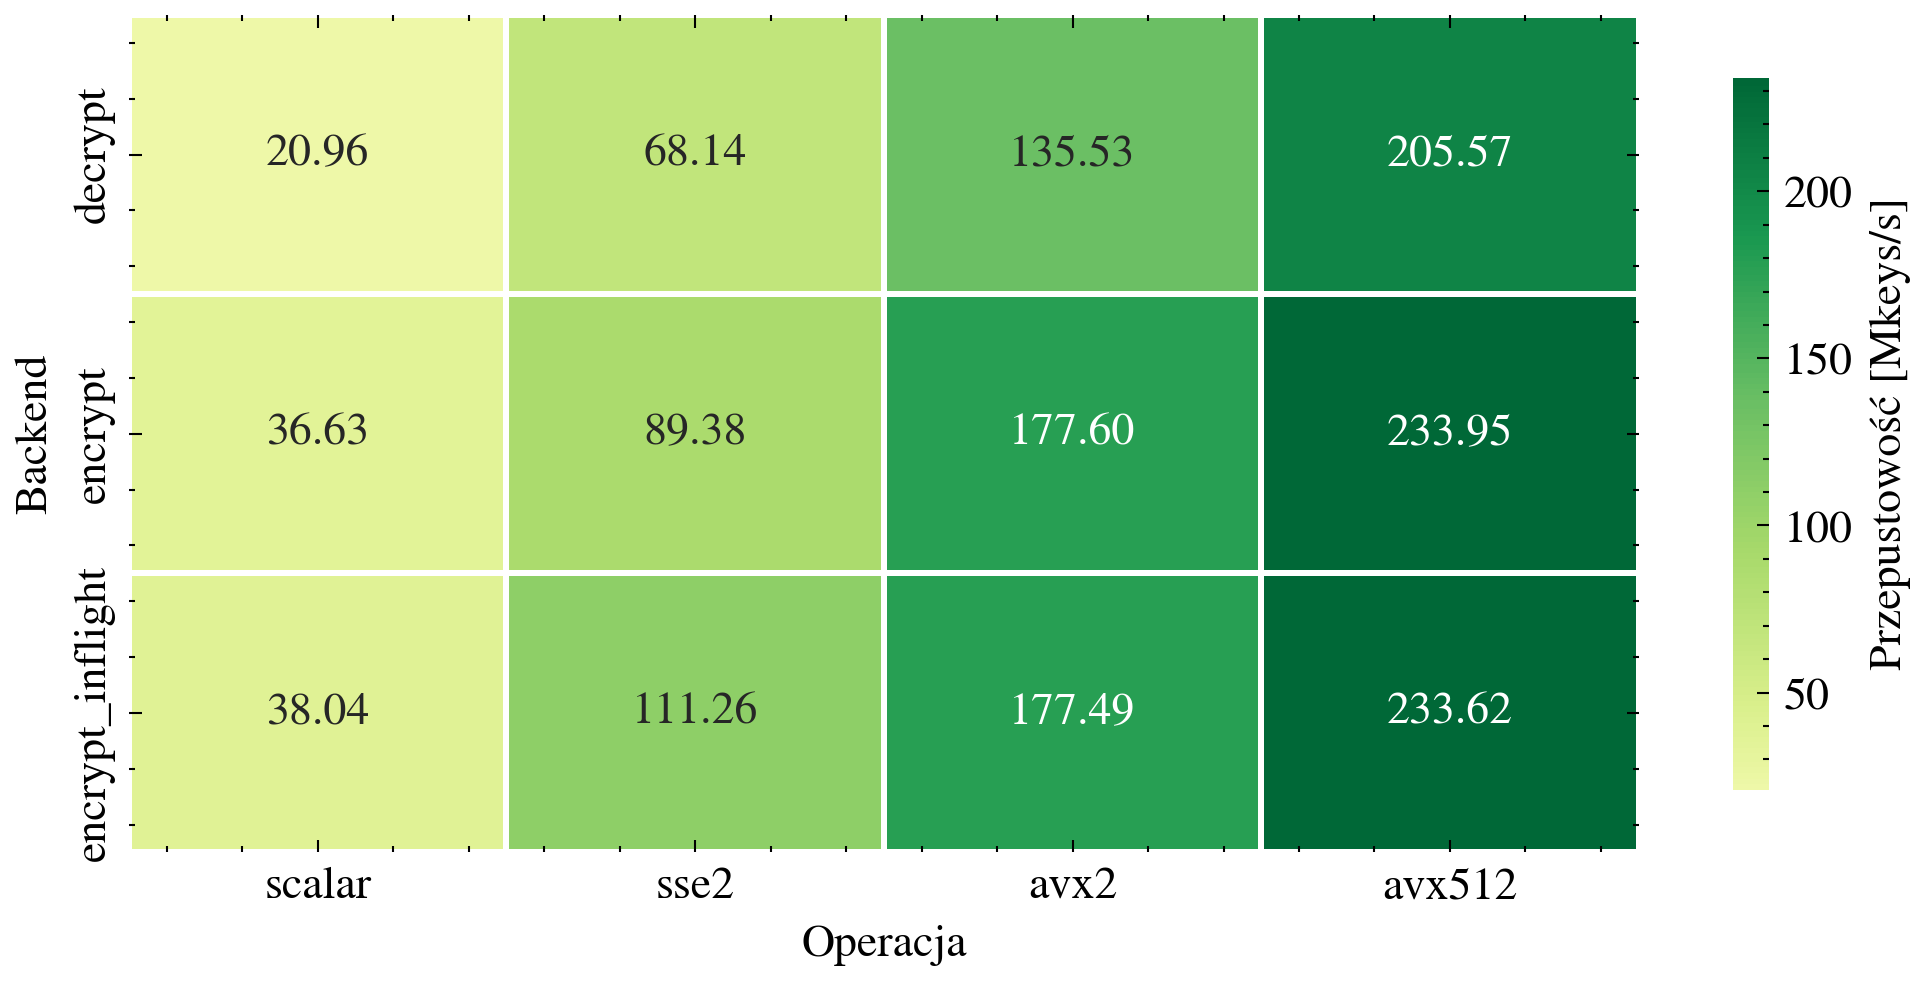

In [11]:
with plt.style.context(['science', 'no-latex', 'bright']):
    fig, ax = plt.subplots(figsize=(7, 3.5))

    sns.heatmap(
        speck_pivot_mean.T,
        ax=ax,
        cmap='RdYlGn',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=1.0,
        cbar_kws={'label': 'Przepustowość [Mkeys/s]', 'shrink': 0.85},
    )

    ax.set_xlabel('Operacja')
    ax.set_ylabel('Backend')

    plt.tight_layout()
    plt.savefig('../svg/speck_pivot_backend_heatmap.svg', bbox_inches='tight', facecolor='white')
    plt.show()

In [12]:
speck_encrypt_inflight = speck_reg[speck_reg['function'] == 'encrypt_inflight']
speck_encrypt_inflight = speck_encrypt_inflight.drop(columns=['function'])
speck_encrypt_inflight

,backend,architecture,version,time_per_iter_ns,ci_95_low_ns,ci_95_high_ns,intercept_ns,r2,keys_per_sec,Mkeys_per_sec
20,avx2,x86_64,128_128,48.693839,48.614950,48.898593,290529.124082,0.999742,8.214592e+07,82.145916
21,avx2,x86_64,128_192,48.158558,47.874213,48.325170,212800.585125,0.999668,8.305897e+07,83.058966
22,avx2,x86_64,128_256,49.852080,49.731386,50.160527,311937.711806,0.999755,8.023737e+07,80.237374
23,avx2,x86_64,32_64,27.889441,27.847283,27.935595,-108570.838925,0.999825,5.736938e+08,573.693817
24,avx2,x86_64,48_72,41.089835,41.071290,41.091487,-57213.022222,0.999997,1.946954e+08,194.695357
25,avx2,x86_64,48_96,42.967950,42.967919,43.001724,52868.106250,0.999997,1.861853e+08,186.185287
26,avx2,x86_64,64_128,36.290037,36.240872,36.345512,14999.842532,0.999859,2.204462e+08,220.446178
27,avx2,x86_64,64_96,34.952896,34.882145,35.026132,258477.457038,0.999456,2.288795e+08,228.879458
28,avx2,x86_64,96_144,62.375961,62.325447,62.392044,304.413690,0.999882,6.412727e+07,64.127269
29,avx2,x86_64,96_96,65.136459,65.116894,65.151808,-10251.479449,0.999980,6.140954e+07,61.409540


In [13]:
scalar_perf = speck_encrypt_inflight[speck_encrypt_inflight['backend'] == 'scalar'].set_index('version')['keys_per_sec']
speck_backend_speedup = speck_encrypt_inflight[speck_encrypt_inflight['backend'] != 'scalar'].copy()

speck_backend_speedup['speedup'] = (
            speck_backend_speedup['keys_per_sec'] / speck_backend_speedup['version'].map(scalar_perf)).round(2)
speck_backend_speedup = speck_backend_speedup.drop(
    columns=['time_per_iter_ns', 'ci_95_high_ns', 'ci_95_low_ns', 'intercept_ns', 'r2', 'keys_per_sec',
             'Mkeys_per_sec'])

version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']
backend_order = ['sse2', 'avx2', 'avx512']

speck_backend_speedup['backend'] = pd.Categorical(speck_backend_speedup['backend'], categories=backend_order,
                                                  ordered=True)
speck_backend_speedup['version'] = pd.Categorical(speck_backend_speedup['version'], categories=version_order,
                                                  ordered=True)

speck_backend_speedup = speck_backend_speedup.pivot_table(index='version', columns='backend',
                                                          values='speedup').reset_index()

speck_backend_speedup.columns.name = None

speck_backend_speedup['version'] = speck_backend_speedup['version'].str.replace('_', '/', regex=False)

speck_backend_speedup = speck_backend_speedup.set_index('version')
speck_backend_speedup

,sse2,avx2,avx512
version,,,
32/64,5.55,8.95,12.05
48/72,3.32,5.24,5.69
48/96,3.87,5.81,6.22
64/96,3.80,5.86,8.13
64/128,3.45,6.14,8.43
96/96,1.26,2.48,3.51
96/144,1.39,2.75,3.94
128/128,1.28,1.85,2.72
128/192,1.53,2.09,2.99


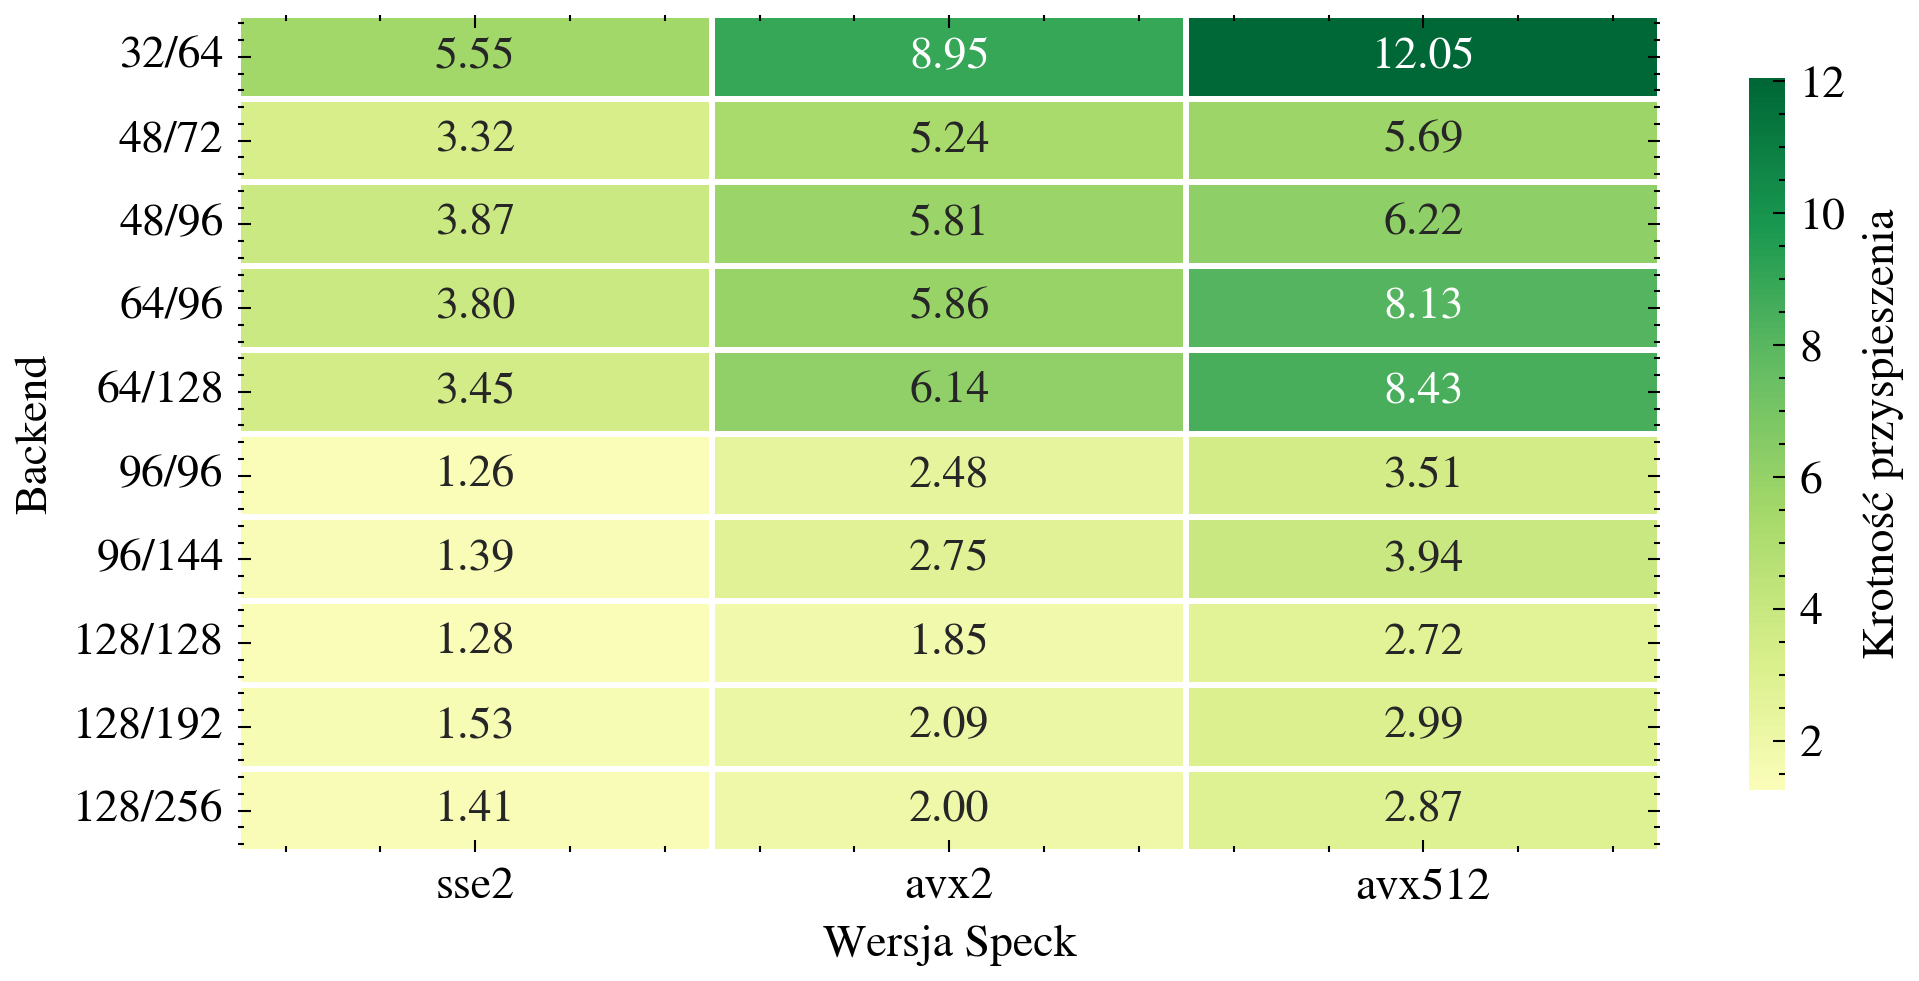

In [14]:
with plt.style.context(['science', 'no-latex', 'bright']):
    fig, ax = plt.subplots(figsize=(7, 3.5))

    sns.heatmap(
        speck_backend_speedup,
        ax=ax,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=1,
        linewidths=1.0,
        cbar_kws={'label': 'Krotność przyspieszenia', 'shrink': 0.85},
    )
    ax.set_xlabel('Wersja Speck')
    ax.set_ylabel('Backend')

    plt.tight_layout()
    plt.savefig('../svg/speck_backend_speedup.svg', bbox_inches='tight', facecolor='white')
    plt.show()

In [15]:
def parse_turbostat(filepath):
    samples = []
    current = {}

    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue

            if parts[0] == "CPU":
                if current:
                    samples.append(current)
                continue

            cpu = "system" if parts[0] == "-" else f"cpu{parts[0]}"
            current[f"{cpu}"] = int(parts[2])
            if len(parts) > 3 and cpu == "system":
                current[f"{cpu}_pkg_watt"] = float(parts[3])

        if current:
            samples.append(current)

    return pd.DataFrame(samples)

In [16]:
bench_turbostat = parse_turbostat("../data/turbostat-bench.txt")
cpu_cols = sorted(
    [c for c in bench_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in bench_turbostat.columns if not c.startswith("cpu")]

bench_turbostat = bench_turbostat[other_cols + cpu_cols]
bench_turbostat

,system,system_pkg_watt,cpu0,cpu1,cpu2,cpu3,cpu4,cpu5,cpu6,cpu7,cpu8,cpu9,cpu10,cpu11,cpu12,cpu13,cpu14,cpu15
0,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159
1,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159
2,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159
3,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159
4,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1479,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159
1480,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159
1481,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159
1482,4235,37.61,4166,4167,4158,4162,4163,4166,4165,4161,4168,4167,4154,4154,4156,4161,4163,4159


In [17]:
cols_to_check = cpu_cols + ["system_pkg_watt"]

results = {}
for c in cols_to_check:
    y = bench_turbostat[c].dropna().values
    x = np.arange(len(y))
    slope, intercept, lo, hi = theilslopes(y, x, 0.95)
    results[c] = {"slope_per_sample": slope, "ci_low": lo, "ci_high": hi, "intercept": intercept}

bench_turbostat_trends = pd.DataFrame(results).T
bench_turbostat_trends

,slope_per_sample,ci_low,ci_high,intercept
cpu0,0.0,0.0,0.0,4166.00
cpu1,0.0,0.0,0.0,4167.00
cpu2,0.0,0.0,0.0,4158.00
cpu3,0.0,0.0,0.0,4162.00
cpu4,0.0,0.0,0.0,4163.00
cpu5,0.0,0.0,0.0,4166.00
cpu6,0.0,0.0,0.0,4165.00
cpu7,0.0,0.0,0.0,4161.00
cpu8,0.0,0.0,0.0,4168.00
cpu9,0.0,0.0,0.0,4167.00


In [18]:
system_turbostat = parse_turbostat("../data/turbostat-system.txt")
cpu_cols = sorted(
    [c for c in system_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in system_turbostat.columns if not c.startswith("cpu")]

system_turbostat = system_turbostat[other_cols + cpu_cols]
system_turbostat

,system,system_pkg_watt,cpu0,cpu1,cpu2,cpu3,cpu4,cpu5,cpu6,cpu7,cpu8,cpu9,cpu10,cpu11,cpu12,cpu13,cpu14,cpu15
0,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154
1,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154
2,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154
3,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154
4,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
588,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154
589,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154
590,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154
591,4156,57.78,4156,4156,4156,4156,4148,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4154


In [19]:
cols_to_check = cpu_cols + ["system_pkg_watt"]

results = {}
for c in cols_to_check:
    y = system_turbostat[c].dropna().values
    x = np.arange(len(y))
    slope, intercept, lo, hi = theilslopes(y, x, 0.95)
    results[c] = {"slope_per_sample": slope, "ci_low": lo, "ci_high": hi, "intercept": intercept}

system_turbostat_trends = pd.DataFrame(results).T
system_turbostat_trends

,slope_per_sample,ci_low,ci_high,intercept
cpu0,0.0,0.0,0.0,4156.00
cpu1,0.0,0.0,0.0,4156.00
cpu2,0.0,0.0,0.0,4156.00
cpu3,0.0,0.0,0.0,4156.00
cpu4,0.0,0.0,0.0,4148.00
cpu5,0.0,0.0,0.0,4156.00
cpu6,0.0,0.0,0.0,4156.00
cpu7,0.0,0.0,0.0,4156.00
cpu8,0.0,0.0,0.0,4156.00
cpu9,0.0,0.0,0.0,4156.00


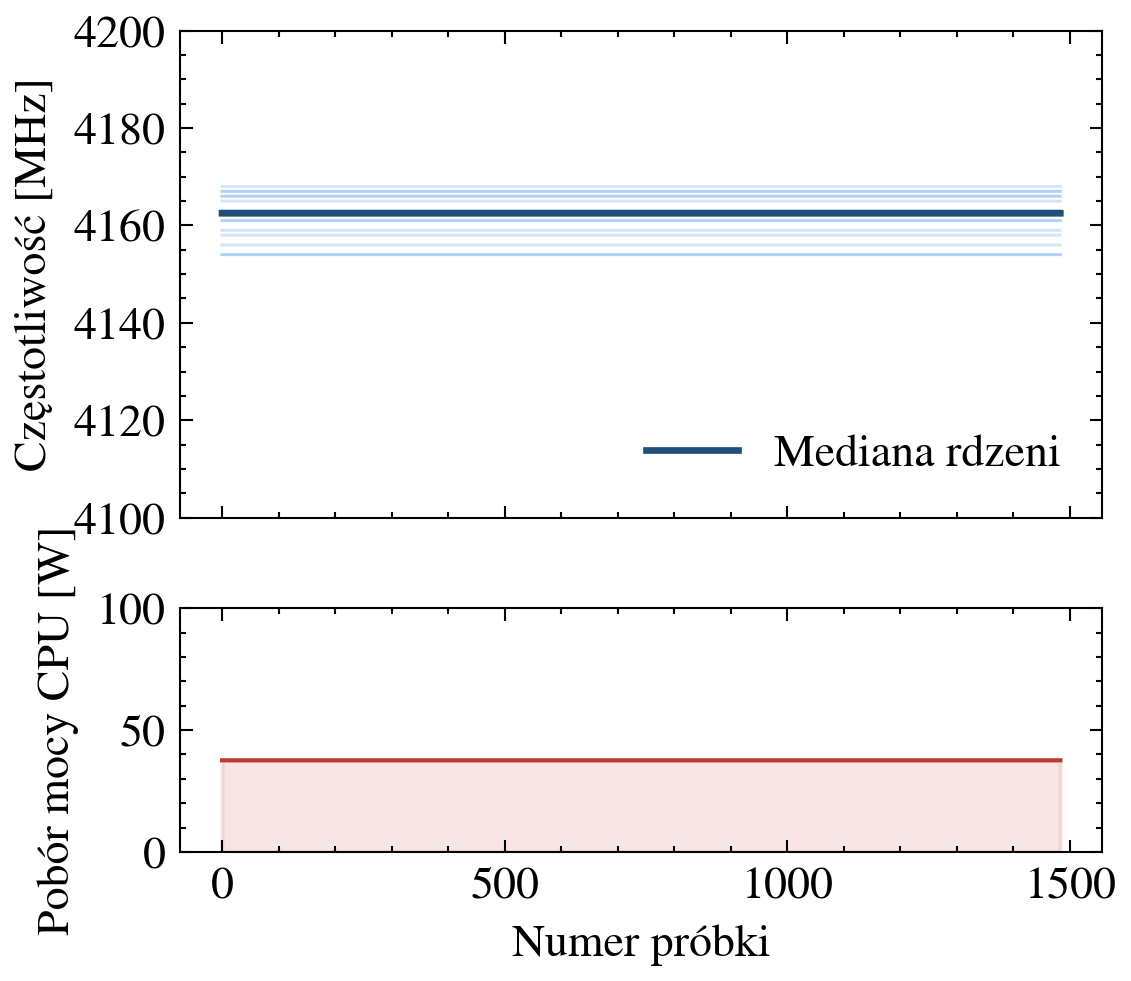

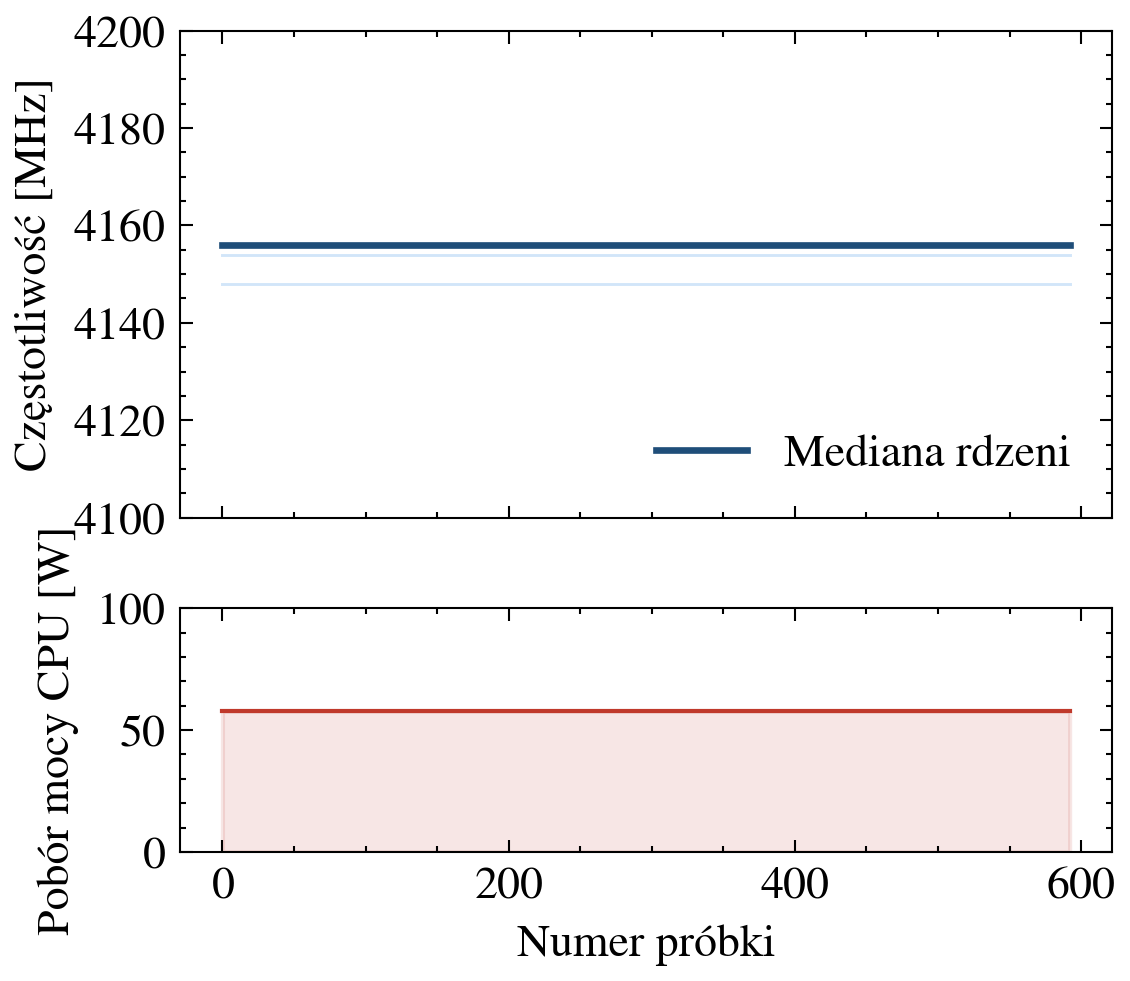

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def prepare_data(df, cpu_cols):
    df_freq = df[cpu_cols].copy()
    df_freq["sample"] = np.arange(len(df_freq))
    df_freq_long = df_freq.melt(
        id_vars="sample", var_name="CPU", value_name="freq"
    )
    df_watt = pd.DataFrame({
        "sample": np.arange(len(df)),
        "watt": df["system_pkg_watt"].values,
    })
    return df_freq_long, df_watt


def plot_turbostat(df_raw, trends_df, cpu_cols, filename):
    df_freq_long, df_watt = prepare_data(df_raw, cpu_cols)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(4, 3.5), sharex=True,
            gridspec_kw={"height_ratios": [2, 1]},
        )

        sns.lineplot(
            data=df_freq_long, x="sample", y="freq", hue="CPU",
            palette=["#4C9BE8"] * len(cpu_cols),
            linewidth=0.7, alpha=0.25, legend=False, ax=ax1,
        )

        median_freq = df_raw[cpu_cols].median(axis=1)
        sns.lineplot(
            x=np.arange(len(median_freq)), y=median_freq.values,
            color="#1F4E79", linewidth=1.6,
            label="Mediana rdzeni", ax=ax1,
        )

        freq_min = trends_df.loc[cpu_cols, "intercept"].min()
        freq_max = trends_df.loc[cpu_cols, "intercept"].max()
        ax1.set_ylim(np.floor(freq_min / 100) * 100, np.ceil(freq_max / 100) * 100)
        ax1.set_ylabel("Częstotliwość [MHz]")
        ax1.set_xlabel("")
        ax1.legend(loc="lower right", frameon=False)

        sns.lineplot(
            data=df_watt, x="sample", y="watt",
            color="#C0392B", linewidth=1.0, ax=ax2,
        )
        ax2.fill_between(
            df_watt["sample"], 0, df_watt["watt"],
            color="#C0392B", alpha=0.12,
        )

        watt_max = df_watt["watt"].max()
        ax2.set_ylim(0, np.ceil(watt_max / 100) * 100)
        ax2.set_ylabel("Pobór mocy CPU [W]")
        ax2.set_xlabel("Numer próbki")

        plt.tight_layout()
        plt.savefig(f'../svg/{filename}.svg',
                    bbox_inches='tight', facecolor='white')
        plt.show()


plot_turbostat(bench_turbostat, bench_turbostat_trends,
               cpu_cols, "turbostat_bench")
plot_turbostat(system_turbostat, system_turbostat_trends,
               cpu_cols, "turbostat_system")

In [21]:
def print_turbostat_summary(df_raw, trends_df, cpu_cols, label):
    freq_min = trends_df.loc[cpu_cols, "intercept"].min()
    freq_max = trends_df.loc[cpu_cols, "intercept"].max()
    watt_med = trends_df.loc["system_pkg_watt", "intercept"]

    freq_slopes = trends_df.loc[cpu_cols, "slope_per_sample"]
    freq_slope_min = freq_slopes.min()
    freq_slope_max = freq_slopes.max()

    watt_slope = trends_df.loc["system_pkg_watt", "slope_per_sample"]
    watt_ci_low = trends_df.loc["system_pkg_watt", "ci_low"]
    watt_ci_high = trends_df.loc["system_pkg_watt", "ci_high"]

    print(f"=== {label} ===")
    print(f"Częstotliwość:")
    print(f"  Theil–Sen β ∈ [{freq_slope_min:.4f}; {freq_slope_max:.4f}] MHz/próbkę")
    print(f"  Mediany per rdzeń: {freq_min:.0f}–{freq_max:.0f} MHz")
    print(f"Pobór mocy CPU:")
    print(f"  Theil–Sen β = {watt_slope:.4f} W/próbkę  "
          f"(95% CI: [{watt_ci_low:.4f}; {watt_ci_high:.4f}])")
    print(f"  Mediana = {watt_med:.2f} W")
    print()


print_turbostat_summary(bench_turbostat, bench_turbostat_trends,
                        cpu_cols, "Bench")
print_turbostat_summary(system_turbostat, system_turbostat_trends,
                        cpu_cols, "System")

=== Bench ===
Częstotliwość:
  Theil–Sen β ∈ [0.0000; 0.0000] MHz/próbkę
  Mediany per rdzeń: 4154–4168 MHz
Pobór mocy CPU:
  Theil–Sen β = 0.0000 W/próbkę  (95% CI: [0.0000; 0.0000])
  Mediana = 37.61 W

=== System ===
Częstotliwość:
  Theil–Sen β ∈ [0.0000; 0.0000] MHz/próbkę
  Mediany per rdzeń: 4148–4156 MHz
Pobór mocy CPU:
  Theil–Sen β = 0.0000 W/próbkę  (95% CI: [0.0000; 0.0000])
  Mediana = 57.78 W



In [22]:
scalar_turbostat = parse_turbostat("../data/turbostat-search-Scalar.txt")
cpu_cols = sorted(
    [c for c in scalar_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in scalar_turbostat.columns if not c.startswith("cpu")]

scalar_turbostat = scalar_turbostat[other_cols + cpu_cols]
scalar_turbostat

,system,system_pkg_watt,cpu0,cpu1,cpu2,cpu3,cpu4,cpu5,cpu6,cpu7,cpu8,cpu9,cpu10,cpu11,cpu12,cpu13,cpu14,cpu15
0,4156,58.8,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156
1,4156,58.8,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156
2,4156,58.8,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156
3,4156,58.8,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156
4,4156,58.8,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156
5,4156,58.8,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156
6,4156,58.8,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156
7,4156,58.8,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156,4156


In [23]:
sse2_turbostat = parse_turbostat("../data/turbostat-search-Sse2.txt")
cpu_cols = sorted(
    [c for c in sse2_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in sse2_turbostat.columns if not c.startswith("cpu")]

sse2_turbostat = sse2_turbostat[other_cols + cpu_cols]
sse2_turbostat

,system,system_pkg_watt,cpu0,cpu1,cpu2,cpu3,cpu4,cpu5,cpu6,cpu7,cpu8,cpu9,cpu10,cpu11,cpu12,cpu13,cpu14,cpu15
0,4149,61.57,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149
1,4149,61.57,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149
2,4149,61.57,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149,4149


In [24]:
avx2_turbostat = parse_turbostat("../data/turbostat-search-Avx2.txt")
cpu_cols = sorted(
    [c for c in avx2_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in avx2_turbostat.columns if not c.startswith("cpu")]

avx2_turbostat = avx2_turbostat[other_cols + cpu_cols]
avx2_turbostat

,system,system_pkg_watt,cpu0,cpu1,cpu2,cpu3,cpu4,cpu5,cpu6,cpu7,cpu8,cpu9,cpu10,cpu11,cpu12,cpu13,cpu14,cpu15
0,4152,63.77,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152
1,4152,63.77,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152,4152


In [25]:
avx512_turbostat = parse_turbostat("../data/turbostat-search-Avx512.txt")
cpu_cols = sorted(
    [c for c in avx512_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in avx512_turbostat.columns if not c.startswith("cpu")]

avx512_turbostat = avx512_turbostat[other_cols + cpu_cols]
avx512_turbostat

,system,system_pkg_watt,cpu0,cpu1,cpu2,cpu3,cpu4,cpu5,cpu6,cpu7,cpu8,cpu9,cpu10,cpu11,cpu12,cpu13,cpu14,cpu15
0,4154,63.46,4150,4150,4150,4150,4150,4150,4150,4150,4150,4150,4150,4150,4150,4150,4150,4150


<Axes: >